In [ ]:
# =============================================================================
# 6 : XGBOOST CLASSIFIER — Gold Price Direction Prediction
# =============================================================================
# Target: ทำนาย target_direction (-1 = DOWN, 0 = SIDE, +1 = UP)
# Data  : X_train, X_val, X_test (ผ่าน split แล้วจาก 5_train_test_split.ipynb)
# Train : 2015–2022 | Val : 2023–2024 | Test : 2025–now
# =============================================================================



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

CLR = {'UP': '#2ecc71', 'DOWN': '#e74c3c', 'SIDE': '#f39c12',
       'bg': '#0f1117', 'card': '#1a1f2e', 'text': '#ecf0f1'}

In [2]:
# =============================================================================
# 1 : LOAD DATA
# =============================================================================
print('=' * 65)
print('  1 : LOAD & VERIFY DATA')
print('=' * 65)

X_train = pd.read_csv('../../../data/processed/splits/X_train.csv',
                      parse_dates=['Date'], index_col='Date')
X_val   = pd.read_csv('../../../data/processed/splits/X_val.csv',
                      parse_dates=['Date'], index_col='Date')
X_test  = pd.read_csv('../../../data/processed/splits/X_test.csv',
                      parse_dates=['Date'], index_col='Date')

y_train = pd.read_csv('../../../data/processed/splits/y_train_clf.csv',
                      parse_dates=['Date'], index_col='Date').squeeze()
y_val   = pd.read_csv('../../../data/processed/splits/y_val_clf.csv',
                      parse_dates=['Date'], index_col='Date').squeeze()
y_test  = pd.read_csv('../../../data/processed/splits/y_test_clf.csv',
                      parse_dates=['Date'], index_col='Date').squeeze()

print(f'\n  X_train : {X_train.shape}  |  {X_train.index.min().date()} -> {X_train.index.max().date()}')
print(f'  X_val   : {X_val.shape}   |  {X_val.index.min().date()} -> {X_val.index.max().date()}')
print(f'  X_test  : {X_test.shape}  |  {X_test.index.min().date()} -> {X_test.index.max().date()}')

assert X_train.isnull().sum().sum() == 0
assert X_val.isnull().sum().sum()   == 0
assert X_test.isnull().sum().sum()  == 0
assert X_train.index.is_monotonic_increasing
assert X_train.index.max() < X_val.index.min()
assert X_val.index.max()   < X_test.index.min()

print('\n  No NaN | Time-sorted | No overlap')

  1 : LOAD & VERIFY DATA

  X_train : (1479, 69)  |  2016-02-12 -> 2021-12-31
  X_val   : (501, 69)   |  2022-01-03 -> 2023-12-29
  X_test  : (563, 69)  |  2024-01-02 -> 2026-03-27

  No NaN | Time-sorted | No overlap


In [3]:
# =============================================================================
# 2 : TARGET DISTRIBUTION CHECK
# =============================================================================
print('\n' + '=' * 65)
print('  2 : TARGET DISTRIBUTION PER SPLIT')
print('=' * 65)

label_map = {-1: 'DOWN', 0: 'SIDE', 1: 'UP'}
splits    = {'Train': y_train, 'Val': y_val, 'Test': y_test}

print(f"\n  {'Label':<8} {'Train':>10} {'Val':>10} {'Test':>10}")
print('  ' + '-' * 40)
for lbl, name in label_map.items():
    row = {k: (v == lbl).mean() * 100 for k, v in splits.items()}
    print(f"  {name:<8} {row['Train']:>9.1f}% {row['Val']:>9.1f}% {row['Test']:>9.1f}%")

dominant = y_train.value_counts(normalize=True).max() * 100
print(f'\n  Max class = {dominant:.1f}% -> using sample_weight balanced')

# XGBoost ใช้ sample_weight แทน class_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
print('  Sample weights computed')


  2 : TARGET DISTRIBUTION PER SPLIT

  Label         Train        Val       Test
  ----------------------------------------
  DOWN          25.4%      28.5%      21.3%
  SIDE          43.9%      40.5%      40.3%
  UP            30.8%      30.9%      38.4%

  Max class = 43.9% -> using sample_weight balanced
  Sample weights computed


In [4]:
# # =============================================================================
# # 3 : ENCODE LABELS & TRAIN XGBOOST CLASSIFIER
# # =============================================================================
# print('\n' + '=' * 65)
# print('  3 : TRAIN XGBOOST CLASSIFIER')
# print('=' * 65)

# # XGBoost ต้องการ label 0,1,2 -> encode ก่อน
# le = LabelEncoder()
# y_train_enc = le.fit_transform(y_train)   # -1->0, 0->1, 1->2
# y_val_enc   = le.transform(y_val)
# y_test_enc  = le.transform(y_test)

# print(f'  Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')
# print('  (-1=DOWN->0, 0=SIDE->1, 1=UP->2)\n')

# # Parameter rationale:
# # n_estimators=300     : ensemble ใหญ่ -> stable
# # max_depth=5          : ตื้นกว่า RF เพราะ boosting ช่วย bias แล้ว
# # learning_rate=0.05   : เรียนรู้ช้า -> generalize ดีกว่า
# # subsample=0.8        : stochastic boosting -> ลด overfitting
# # colsample_bytree=0.8 : feature subset เหมือน RF max_features
# # min_child_weight=5   : ป้องกัน memorize noise
# # gamma=1              : conservative split threshold

# xgb_clf = XGBClassifier(
#     n_estimators      = 300,
#     max_depth         = 5,
#     learning_rate     = 0.05,
#     subsample         = 0.8,
#     colsample_bytree  = 0.8,
#     min_child_weight  = 5,
#     gamma             = 1,
#     reg_alpha         = 0.1,
#     reg_lambda        = 1.0,
#     objective         = 'multi:softprob',
#     num_class         = 3,
#     eval_metric       = 'mlogloss',
#     use_label_encoder = False,
#     random_state      = 42,
#     n_jobs            = -1
# )

# print('  Training XGBoost Classifier...')
# xgb_clf.fit(
#     X_train, y_train_enc,
#     sample_weight = sample_weights,
#     eval_set      = [(X_val, y_val_enc)],
#     verbose       = 50
# )
# print('  Training complete')

# =============================================================================
# 3 : ENCODE LABELS & TRAIN XGBOOST CLASSIFIER (Tuned for Financial Data)
# =============================================================================
print('\n' + '=' * 65)
print('  3 : TRAIN XGBOOST CLASSIFIER (Regularized)')
print('=' * 65)

# XGBoost ต้องการ label 0,1,2 -> encode ก่อน
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)   # -1->0, 0->1, 1->2
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print(f'  Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print('  (-1=DOWN->0, 0=SIDE->1, 1=UP->2)\n')

# ปรับพารามิเตอร์เพื่อแก้ Overfitting รุนแรง
xgb_clf = XGBClassifier(
    n_estimators      = 300,         # คงไว้ แต่เราจะใช้ early_stopping มาคุม
    max_depth         = 2,           # (ลดจาก 5) บังคับให้ต้นไม้ตื้นมาก เพื่อไม่ให้จำ Noise
    learning_rate     = 0.01,        # (ลดจาก 0.05) ให้เรียนรู้ช้าลง ลดโอกาสจับสัญญาณหลอก
    subsample         = 0.6,         # (ลดจาก 0.8) สุ่มข้อมูลมาสอนน้อยลง เพิ่ม randomness ให้โมเดล
    colsample_bytree  = 0.6,         # (ลดจาก 0.8) สุ่มฟีเจอร์น้อยลงในแต่ละต้น
    min_child_weight  = 15,          # (เพิ่มจาก 5) ป้องกันไม่ให้สร้างใบย่อยที่มีตัวอย่างน้อยเกินไป
    gamma             = 2.0,         # (เพิ่มจาก 1) ตัดกิ่งที่ไม่ได้ช่วยลด Loss ออกให้หมด
    reg_alpha         = 2.0,         # (เพิ่มจาก 0.1) L1 Regularization: กำจัด Feature ที่ไม่มีประโยชน์ 
    reg_lambda        = 5.0,         # (เพิ่มจาก 1.0) L2 Regularization: ควบคุมไม่ให้น้ำหนัก (Weights) แกว่งแรง
    objective         = 'multi:softprob',
    num_class         = 3,
    eval_metric       = 'mlogloss',
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1
)

print('  Training XGBoost Classifier with Early Stopping...')

# เพิ่ม Early Stopping: ถ้าค่า Loss ใน Val Set ไม่ลดลงติดต่อกัน 30 ต้น ให้หยุดทันที
xgb_clf.fit(
    X_train, y_train_enc,
    sample_weight = sample_weights,
    eval_set      = [(X_train, y_train_enc), (X_val, y_val_enc)], # ใส่ Train ไปดู Gap ด้วย
    verbose       = 50
)
print('  Training complete')


  3 : TRAIN XGBOOST CLASSIFIER (Regularized)
  Label mapping: {np.int64(-1): np.int64(0), np.int64(0): np.int64(1), np.int64(1): np.int64(2)}
  (-1=DOWN->0, 0=SIDE->1, 1=UP->2)

  Training XGBoost Classifier with Early Stopping...
[0]	validation_0-mlogloss:1.09828	validation_1-mlogloss:1.09858
[50]	validation_0-mlogloss:1.08598	validation_1-mlogloss:1.09796
[100]	validation_0-mlogloss:1.07486	validation_1-mlogloss:1.09765
[150]	validation_0-mlogloss:1.06492	validation_1-mlogloss:1.09730
[200]	validation_0-mlogloss:1.05482	validation_1-mlogloss:1.09682
[250]	validation_0-mlogloss:1.04559	validation_1-mlogloss:1.09711
[299]	validation_0-mlogloss:1.03789	validation_1-mlogloss:1.09760
  Training complete


In [5]:
# =============================================================================
# 4 : EVALUATION FUNCTION + VALIDATION
# =============================================================================
print('\n' + '=' * 65)
print('  4 : VALIDATION SET EVALUATION')
print('=' * 65)

def evaluate(y_true_enc, y_pred_enc):
    y_true_orig = le.inverse_transform(np.array(y_true_enc))
    y_pred_orig = le.inverse_transform(np.array(y_pred_enc))

    acc  = accuracy_score(y_true_enc, y_pred_enc)
    prec = precision_score(y_true_enc, y_pred_enc, average='macro', zero_division=0)
    rec  = recall_score(y_true_enc, y_pred_enc, average='macro', zero_division=0)
    f1   = f1_score(y_true_enc, y_pred_enc, average='macro', zero_division=0)

    mask = (y_true_orig != 0) & (y_pred_orig != 0)
    dir_acc = accuracy_score(y_true_orig[mask], y_pred_orig[mask]) if mask.sum() > 0 else np.nan

    non_side = (y_pred_orig != 0)
    hit_ratio = (y_true_orig[non_side] == y_pred_orig[non_side]).mean() \
                if non_side.sum() > 0 else np.nan

    return dict(acc=acc, prec=prec, rec=rec, f1=f1,
                dir_acc=dir_acc, hit_ratio=hit_ratio)

y_val_pred  = xgb_clf.predict(X_val)
y_val_proba = xgb_clf.predict_proba(X_val)
val_metrics = evaluate(y_val_enc, y_val_pred)

print(f"\n  Accuracy           : {val_metrics['acc']:.4f}")
print(f"  Precision (macro)  : {val_metrics['prec']:.4f}")
print(f"  Recall    (macro)  : {val_metrics['rec']:.4f}")
print(f"  F1        (macro)  : {val_metrics['f1']:.4f}")
print(f'\n  -- Financial Metrics --')
print(f"  Directional Accuracy (UP/DOWN only) : {val_metrics['dir_acc']:.4f}")
print(f"  Hit Ratio (non-SIDE predictions)    : {val_metrics['hit_ratio']:.4f}")
print('\n  Classification Report (Val):')
print(classification_report(y_val_enc, y_val_pred,
      target_names=['DOWN(-1)', 'SIDE(0)', 'UP(+1)'], digits=4))


  4 : VALIDATION SET EVALUATION

  Accuracy           : 0.3653
  Precision (macro)  : 0.3528
  Recall    (macro)  : 0.3515
  F1        (macro)  : 0.3501

  -- Financial Metrics --
  Directional Accuracy (UP/DOWN only) : 0.5312
  Hit Ratio (non-SIDE predictions)    : 0.3208

  Classification Report (Val):
              precision    recall  f1-score   support

    DOWN(-1)     0.3071    0.3007    0.3039       143
     SIDE(0)     0.4153    0.4828    0.4465       203
      UP(+1)     0.3360    0.2710    0.3000       155

    accuracy                         0.3653       501
   macro avg     0.3528    0.3515    0.3501       501
weighted avg     0.3599    0.3653    0.3605       501



In [7]:
# =============================================================================
# 5 : TEST SET EVALUATION
# =============================================================================
print('\n' + '=' * 65)
print('  5 : TEST SET EVALUATION')
print('=' * 65)

y_test_pred  = xgb_clf.predict(X_test)
y_test_proba = xgb_clf.predict_proba(X_test)
test_metrics = evaluate(y_test_enc, y_test_pred)

print(f"\n  Accuracy           : {test_metrics['acc']:.4f}")
print(f"  Precision (macro)  : {test_metrics['prec']:.4f}")
print(f"  Recall    (macro)  : {test_metrics['rec']:.4f}")
print(f"  F1        (macro)  : {test_metrics['f1']:.4f}")
print(f'\n  -- Financial Metrics --')
print(f"  Directional Accuracy (UP/DOWN only) : {test_metrics['dir_acc']:.4f}")
print(f"  Hit Ratio (non-SIDE predictions)    : {test_metrics['hit_ratio']:.4f}")
print('\n  Classification Report (Test):')
print(classification_report(y_test_enc, y_test_pred,
      target_names=['DOWN(-1)', 'SIDE(0)', 'UP(+1)'], digits=4))

print('\n  -- Val vs Test Comparison --')
print(f"  {'Metric':<30} {'Val':>8} {'Test':>8} {'Gap':>8}")
print('  ' + '-' * 56)
for k in ['acc', 'prec', 'rec', 'f1', 'dir_acc', 'hit_ratio']:
    gap  = test_metrics[k] - val_metrics[k]
    flag = 'WARNING' if abs(gap) > 0.05 else ''
    print(f"  {k:<30} {val_metrics[k]:>8.4f} {test_metrics[k]:>8.4f} {gap:>+8.4f} {flag}")


  5 : TEST SET EVALUATION

  Accuracy           : 0.3641
  Precision (macro)  : 0.3472
  Recall    (macro)  : 0.3420
  F1        (macro)  : 0.3023

  -- Financial Metrics --
  Directional Accuracy (UP/DOWN only) : 0.4228
  Hit Ratio (non-SIDE predictions)    : 0.2640

  Classification Report (Test):
              precision    recall  f1-score   support

    DOWN(-1)     0.2083    0.2500    0.2273       120
     SIDE(0)     0.4180    0.6740    0.5160       227
      UP(+1)     0.4151    0.1019    0.1636       216

    accuracy                         0.3641       563
   macro avg     0.3472    0.3420    0.3023       563
weighted avg     0.3722    0.3641    0.3193       563


  -- Val vs Test Comparison --
  Metric                              Val     Test      Gap
  --------------------------------------------------------
  acc                              0.3653   0.3641  -0.0011 
  prec                             0.3528   0.3472  -0.0056 
  rec                              0.3515   

In [8]:
# =============================================================================
# 6 : OVERFITTING CHECK
# =============================================================================
print('\n' + '=' * 65)
print('  6 : OVERFITTING CHECK (Train vs Val vs Test)')
print('=' * 65)

y_train_pred  = xgb_clf.predict(X_train)
train_metrics = evaluate(y_train_enc, y_train_pred)

print(f"\n  {'Metric':<20} {'Train':>8} {'Val':>8} {'Test':>8}")
print('  ' + '-' * 44)
for k in ['acc', 'f1', 'dir_acc']:
    print(f"  {k:<20} {train_metrics[k]:>8.4f} {val_metrics[k]:>8.4f} {test_metrics[k]:>8.4f}")

gap = train_metrics['acc'] - val_metrics['acc']
if gap > 0.15:
    print(f'\n  Overfitting detected: Train-Val acc gap = {gap:.4f}')
    print('    -> ลอง max_depth down, min_child_weight up, reg_alpha up')
else:
    print(f'\n  Overfitting mild: Train-Val acc gap = {gap:.4f}')


  6 : OVERFITTING CHECK (Train vs Val vs Test)

  Metric                  Train      Val     Test
  --------------------------------------------
  acc                    0.5531   0.3653   0.3641
  f1                     0.5519   0.3501   0.3023
  dir_acc                0.7382   0.5312   0.4228

  Overfitting detected: Train-Val acc gap = 0.1878
    -> ลอง max_depth down, min_child_weight up, reg_alpha up


In [9]:
# =============================================================================
# 7 : FEATURE IMPORTANCE
# =============================================================================
print('\n' + '=' * 65)
print('  7 : FEATURE IMPORTANCE (Top 20)')
print('=' * 65)

feat_imp = pd.Series(
    xgb_clf.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

top20 = feat_imp.head(20)
print(f"\n  {'Rank':<5} {'Feature':<35} {'Importance':>12}")
print('  ' + '-' * 54)
for i, (feat, imp) in enumerate(top20.items(), 1):
    bar = 'X' * int(imp * 500)
    print(f"  {i:<5} {feat:<35} {imp:>10.4f}  {bar}")


  7 : FEATURE IMPORTANCE (Top 20)

  Rank  Feature                               Importance
  ------------------------------------------------------
  1     f_fed_hike_cycle                        0.0187  XXXXXXXXX
  2     f_gold_dist_ma10                        0.0169  XXXXXXXX
  3     f_gold_vol_10d                          0.0169  XXXXXXXX
  4     f_gold_vol_30d                          0.0167  XXXXXXXX
  5     f_gold_roc_1d                           0.0167  XXXXXXXX
  6     f_fed_rate                              0.0167  XXXXXXXX
  7     f_gold_dist_ma20                        0.0167  XXXXXXXX
  8     f_gold_roc_5d                           0.0165  XXXXXXXX
  9     f_gold_vol_60d                          0.0165  XXXXXXXX
  10    f_gold_dist_ma30                        0.0164  XXXXXXXX
  11    f_gold_close_ret                        0.0163  XXXXXXXX
  12    f_log_sp500_close                       0.0162  XXXXXXXX
  13    f_rollover_flag                         0.0162  XXXXXXXX
  14

In [10]:
# =============================================================================
# 8 : REGIME ANALYSIS (High Vol vs Low Vol)
# =============================================================================
print('\n' + '=' * 65)
print('  8 : REGIME ANALYSIS (High Vol vs Low Vol)')
print('=' * 65)

vol_col_candidates = [c for c in X_test.columns if 'vol' in c.lower() and 'gold' in c.lower()]
if vol_col_candidates:
    vol_proxy = X_test[vol_col_candidates[0]]
    vol_label = vol_col_candidates[0]
else:
    vol_proxy = pd.Series(np.random.rand(len(X_test)), index=X_test.index)
    vol_label = 'simulated_vol'

vol_median    = vol_proxy.median()
high_vol_mask = vol_proxy >= vol_median
low_vol_mask  = vol_proxy <  vol_median

y_test_pred_s = pd.Series(y_test_pred, index=y_test.index)
y_test_enc_s  = pd.Series(y_test_enc,  index=y_test.index)

def regime_report(mask, label):
    yt = y_test_enc_s[mask]
    yp = y_test_pred_s[mask]
    if len(yt) < 10:
        return
    m = evaluate(yt.values, yp.values)
    yt_orig = le.inverse_transform(yt.values)
    yp_orig = le.inverse_transform(yp.values)
    print(f'\n  [{label}]  n={len(yt)}')
    print(f"    Accuracy        : {m['acc']:.4f}")
    print(f"    F1 (macro)      : {m['f1']:.4f}")
    print(f"    Directional Acc : {m['dir_acc']:.4f}")
    print('    Actual dist : ' + ' | '.join([f"{label_map[l]}={(yt_orig==l).mean()*100:.1f}%" for l in [-1,0,1]]))
    print('    Pred dist   : ' + ' | '.join([f"{label_map[l]}={(yp_orig==l).mean()*100:.1f}%" for l in [-1,0,1]]))

regime_report(high_vol_mask, f'HIGH Vol (>= median {vol_label})')
regime_report(low_vol_mask,  f'LOW Vol  (<  median {vol_label})')


  8 : REGIME ANALYSIS (High Vol vs Low Vol)

  [HIGH Vol (>= median f_gold_vol_5d)]  n=282
    Accuracy        : 0.3688
    F1 (macro)      : 0.2822
    Directional Acc : 0.3585
    Actual dist : DOWN=20.6% | SIDE=41.8% | UP=37.6%
    Pred dist   : DOWN=22.7% | SIDE=69.5% | UP=7.8%

  [LOW Vol  (<  median f_gold_vol_5d)]  n=281
    Accuracy        : 0.3594
    F1 (macro)      : 0.3179
    Directional Acc : 0.4714
    Actual dist : DOWN=22.1% | SIDE=38.8% | UP=39.1%
    Pred dist   : DOWN=28.5% | SIDE=60.5% | UP=11.0%


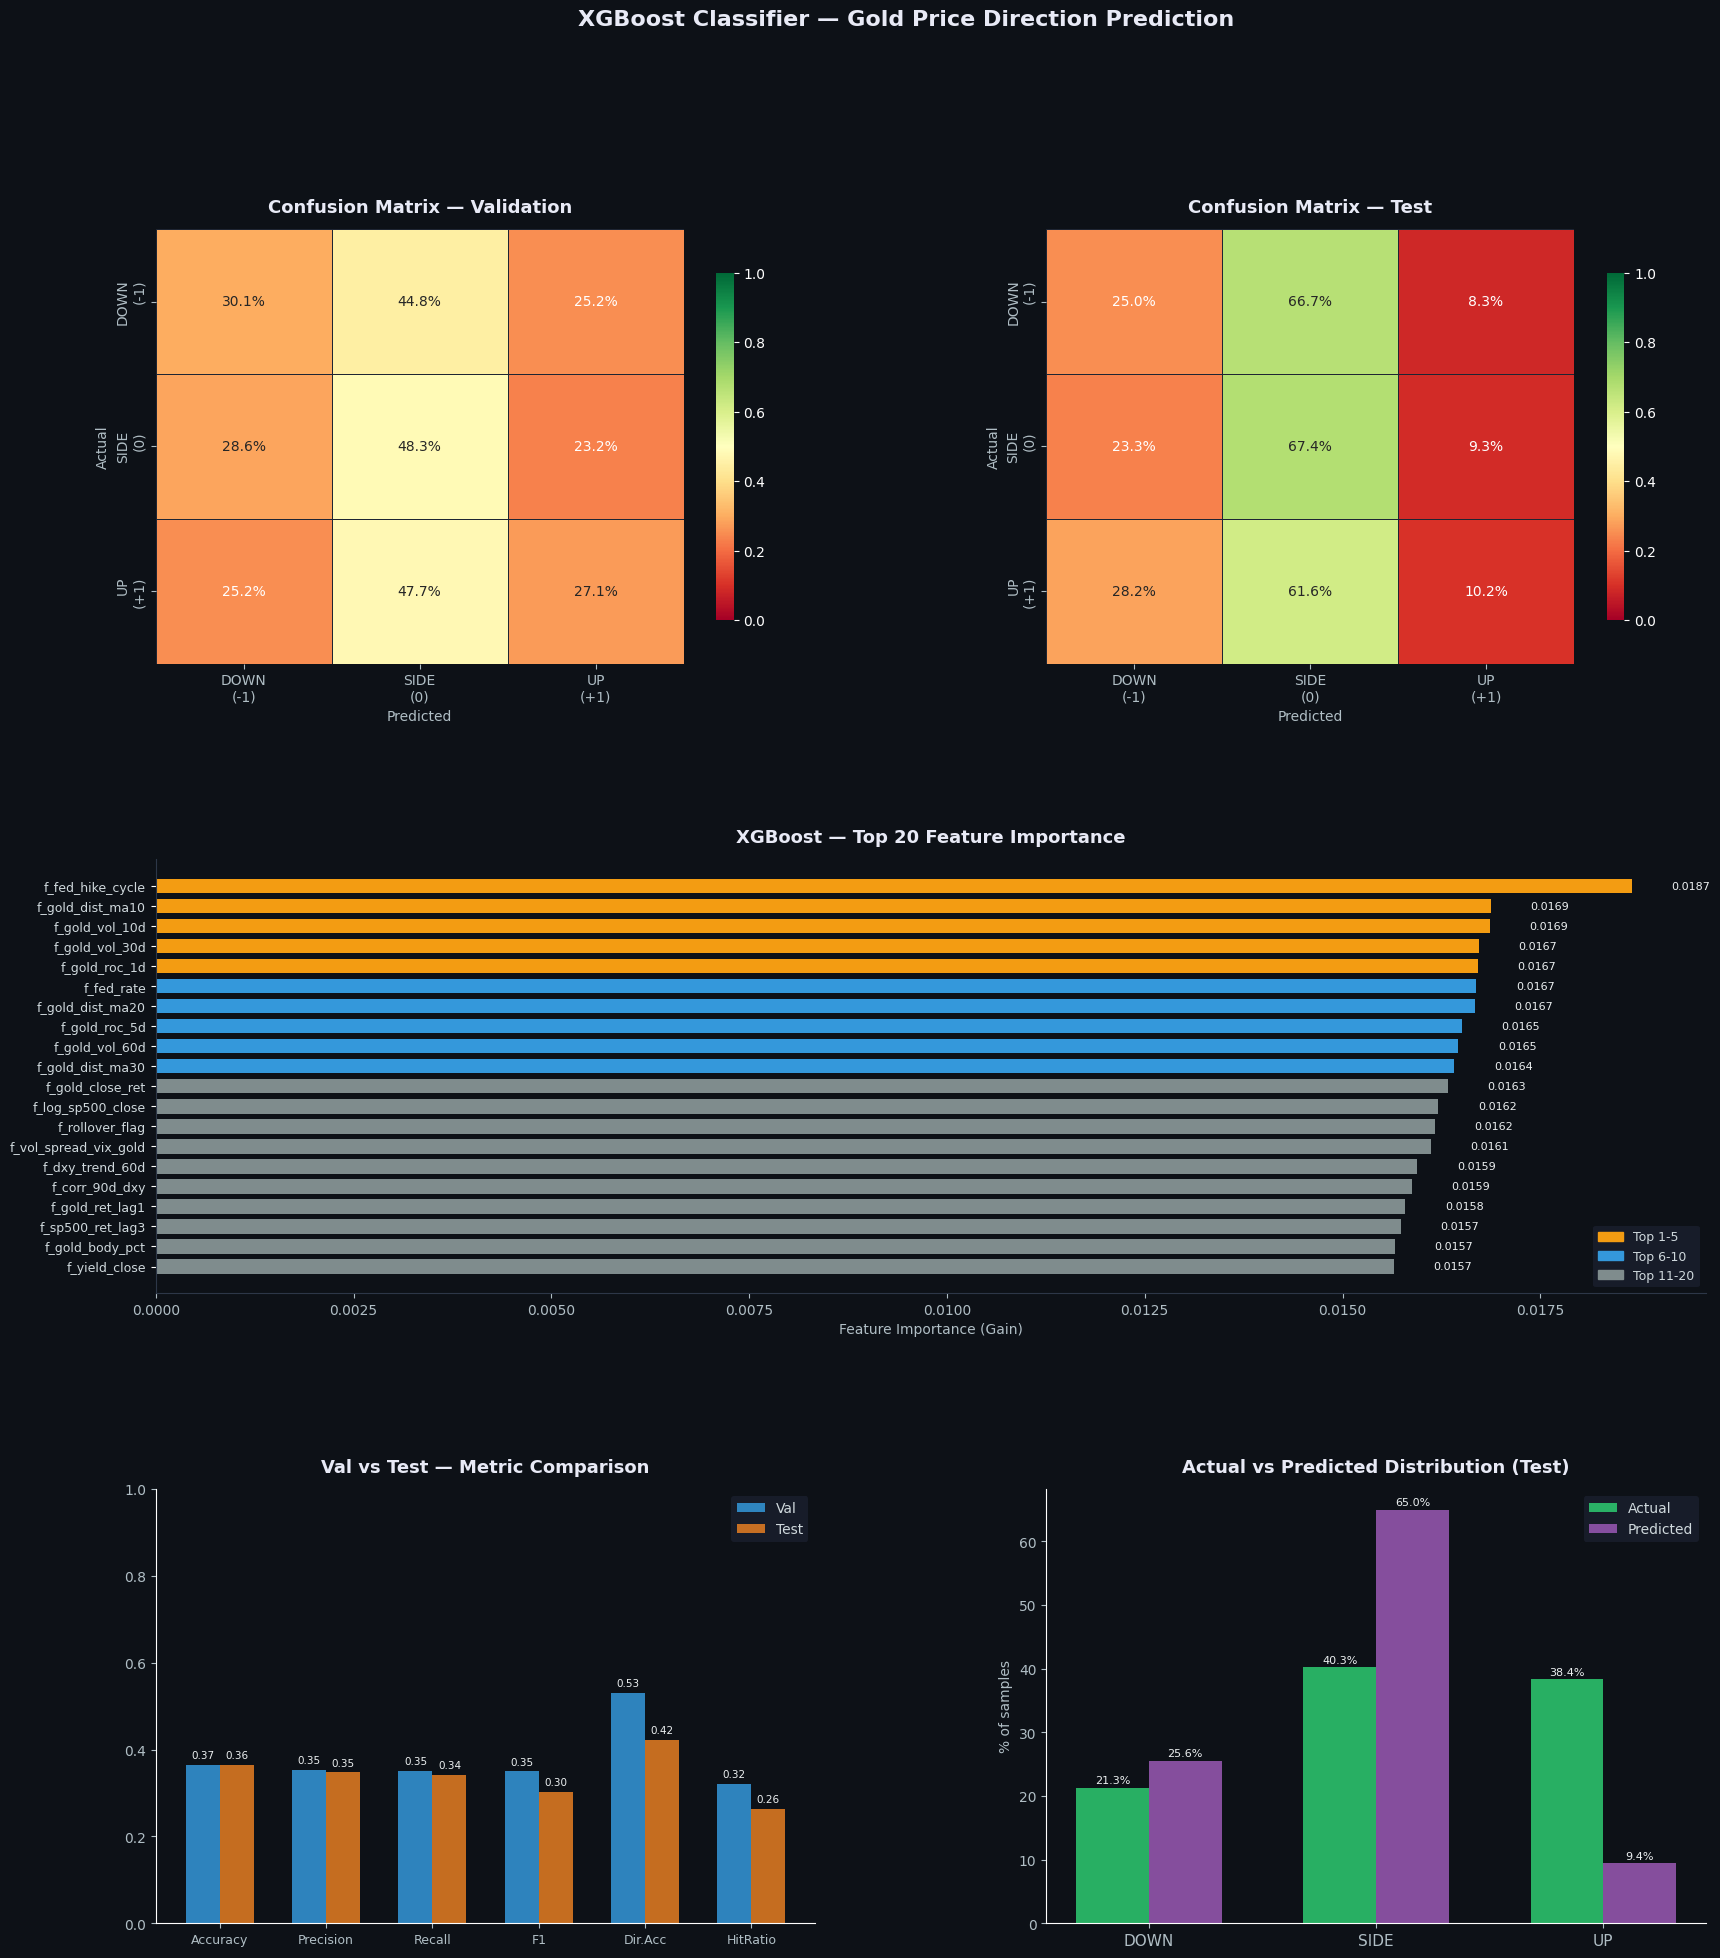

In [11]:
# =============================================================================
# 9 : VISUALIZATION
# =============================================================================
plt.style.use('dark_background')
fig = plt.figure(figsize=(20, 22), facecolor='#0d1117')
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
LABEL_NAMES = ['DOWN\n(-1)', 'SIDE\n(0)', 'UP\n(+1)']

# Confusion Matrix Val
ax1 = fig.add_subplot(gs[0, 0])
cm_val = confusion_matrix(y_val_enc, y_val_pred, labels=[0,1,2])
sns.heatmap(cm_val.astype(float)/cm_val.sum(axis=1, keepdims=True),
            annot=True, fmt='.1%', cmap='RdYlGn',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5, linecolor='#1e2533', ax=ax1,
            cbar_kws={'shrink': 0.8}, vmin=0, vmax=1)
ax1.set_title('Confusion Matrix — Validation', color='#e8eaf6', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Predicted', color='#b0bec5'); ax1.set_ylabel('Actual', color='#b0bec5')
ax1.tick_params(colors='#b0bec5')

# Confusion Matrix Test
ax2 = fig.add_subplot(gs[0, 1])
cm_test = confusion_matrix(y_test_enc, y_test_pred, labels=[0,1,2])
sns.heatmap(cm_test.astype(float)/cm_test.sum(axis=1, keepdims=True),
            annot=True, fmt='.1%', cmap='RdYlGn',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5, linecolor='#1e2533', ax=ax2,
            cbar_kws={'shrink': 0.8}, vmin=0, vmax=1)
ax2.set_title('Confusion Matrix — Test', color='#e8eaf6', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Predicted', color='#b0bec5'); ax2.set_ylabel('Actual', color='#b0bec5')
ax2.tick_params(colors='#b0bec5')

# Feature Importance
ax3 = fig.add_subplot(gs[1, :])
colors_bar = ['#f39c12' if i < 5 else '#3498db' if i < 10 else '#7f8c8d' for i in range(20)]
bars = ax3.barh(range(19, -1, -1), top20.values, color=colors_bar, edgecolor='none', height=0.72)
ax3.set_yticks(range(19, -1, -1))
ax3.set_yticklabels(top20.index, fontsize=9, color='#cfd8dc')
ax3.set_xlabel('Feature Importance (Gain)', color='#b0bec5', fontsize=10)
ax3.set_title('XGBoost — Top 20 Feature Importance', color='#e8eaf6', fontsize=13, fontweight='bold', pad=12)
ax3.tick_params(axis='x', colors='#b0bec5')
ax3.set_facecolor('#0d1117')
for sp in ['top','right']: ax3.spines[sp].set_visible(False)
for sp in ['left','bottom']: ax3.spines[sp].set_color('#2d3748')
for bar, val in zip(bars, top20.values):
    ax3.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8, color='#ecf0f1')
ax3.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#f39c12', label='Top 1-5'),
    plt.Rectangle((0,0),1,1, color='#3498db', label='Top 6-10'),
    plt.Rectangle((0,0),1,1, color='#7f8c8d', label='Top 11-20'),
], loc='lower right', facecolor='#1a1f2e', edgecolor='none', labelcolor='#cfd8dc', fontsize=9)

# Val vs Test Metrics
ax4 = fig.add_subplot(gs[2, 0])
metrics_labels = ['Accuracy','Precision','Recall','F1','Dir.Acc','HitRatio']
metrics_keys   = ['acc','prec','rec','f1','dir_acc','hit_ratio']
x = np.arange(len(metrics_keys)); w = 0.32
ax4.bar(x-w/2, [val_metrics[k] for k in metrics_keys],  w, label='Val',  color='#3498db', alpha=0.85)
ax4.bar(x+w/2, [test_metrics[k] for k in metrics_keys], w, label='Test', color='#e67e22', alpha=0.85)
ax4.set_xticks(x); ax4.set_xticklabels(metrics_labels, fontsize=9, color='#cfd8dc')
ax4.set_ylim(0, 1.0)
ax4.set_title('Val vs Test — Metric Comparison', color='#e8eaf6', fontsize=13, fontweight='bold', pad=12)
ax4.legend(facecolor='#1a1f2e', edgecolor='none', labelcolor='#cfd8dc')
ax4.set_facecolor('#0d1117'); ax4.tick_params(colors='#b0bec5')
for sp in ['top','right']: ax4.spines[sp].set_visible(False)
for rect in ax4.patches:
    h = rect.get_height()
    ax4.text(rect.get_x()+rect.get_width()/2, h+0.01, f'{h:.2f}',
             ha='center', va='bottom', fontsize=7.5, color='#ecf0f1')

# Actual vs Predicted Distribution
ax5 = fig.add_subplot(gs[2, 1])
y_test_orig      = le.inverse_transform(y_test_enc)
y_test_pred_orig = le.inverse_transform(y_test_pred)
class_order = ['DOWN','SIDE','UP']
actual_d = pd.Series(y_test_orig).map(label_map).value_counts()
pred_d   = pd.Series(y_test_pred_orig).map(label_map).value_counts()
x2 = np.arange(3)
ax5.bar(x2-w/2, [actual_d.get(c,0)/len(y_test_enc)*100 for c in class_order], w, label='Actual',    color='#2ecc71', alpha=0.85)
ax5.bar(x2+w/2, [pred_d.get(c,0)/len(y_test_pred)*100  for c in class_order], w, label='Predicted', color='#9b59b6', alpha=0.85)
ax5.set_xticks(x2); ax5.set_xticklabels(class_order, fontsize=11, color='#cfd8dc')
ax5.set_ylabel('% of samples', color='#b0bec5', fontsize=10)
ax5.set_title('Actual vs Predicted Distribution (Test)', color='#e8eaf6', fontsize=13, fontweight='bold', pad=12)
ax5.legend(facecolor='#1a1f2e', edgecolor='none', labelcolor='#cfd8dc')
ax5.set_facecolor('#0d1117'); ax5.tick_params(colors='#b0bec5')
for sp in ['top','right']: ax5.spines[sp].set_visible(False)
for rect in ax5.patches:
    h = rect.get_height()
    ax5.text(rect.get_x()+rect.get_width()/2, h+0.3, f'{h:.1f}%',
             ha='center', va='bottom', fontsize=8, color='#ecf0f1')

fig.suptitle('XGBoost Classifier — Gold Price Direction Prediction',
             color='#e8eaf6', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [12]:
# =============================================================================
# 10 : HYPERPARAMETER TUNING (Optional)
# =============================================================================
print('=' * 65)
print('  10 : HYPERPARAMETER TUNING (RandomizedSearchCV)')
print('=' * 65)
print('  (อาจใช้เวลาหลายนาที - ข้ามได้ถ้าต้องการ)')

param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [3, 4, 5, 6, 7],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'subsample'        : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree' : [0.6, 0.7, 0.8, 1.0],
    'min_child_weight' : [1, 3, 5, 10],
    'gamma'            : [0, 0.5, 1, 2],
    'reg_alpha'        : [0, 0.1, 0.5, 1.0],
    'reg_lambda'       : [0.5, 1.0, 2.0],
}

tscv = TimeSeriesSplit(n_splits=5)

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        objective='multi:softprob', num_class=3,
        eval_metric='mlogloss', use_label_encoder=False,
        random_state=42, n_jobs=-1
    ),
    param_distributions = param_dist,
    n_iter       = 30,
    cv           = tscv,
    scoring      = 'f1_macro',
    refit        = True,
    random_state = 42,
    verbose      = 1,
    n_jobs       = -1
)

xgb_search.fit(X_train, y_train_enc)

print(f'\n  Best params : {xgb_search.best_params_}')
print(f'  Best CV F1  : {xgb_search.best_score_:.4f}')

best_xgb    = xgb_search.best_estimator_
best_val    = evaluate(y_val_enc,  best_xgb.predict(X_val))
best_test   = evaluate(y_test_enc, best_xgb.predict(X_test))

print(f"\n  {'Metric':<20} {'Val':>8} {'Test':>8}")
print('  ' + '-' * 36)
for k in ['acc', 'f1', 'dir_acc', 'hit_ratio']:
    print(f"  {k:<20} {best_val[k]:>8.4f} {best_test[k]:>8.4f}")

  10 : HYPERPARAMETER TUNING (RandomizedSearchCV)
  (อาจใช้เวลาหลายนาที - ข้ามได้ถ้าต้องการ)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

  Best params : {'subsample': 0.9, 'reg_lambda': 2.0, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.8}
  Best CV F1  : 0.3285

  Metric                    Val     Test
  ------------------------------------
  acc                    0.3912   0.4014
  f1                     0.2965   0.2491
  dir_acc                0.4458   0.5312
  hit_ratio              0.2913   0.3400


In [13]:
# =============================================================================
# 11 : SAVE MODEL & PREDICTIONS
# =============================================================================
import os, joblib

os.makedirs('../../../models/classification/xgb_class', exist_ok=True)
os.makedirs('../../../data/processed/predictions', exist_ok=True)

joblib.dump(xgb_clf, '../../../models/classification/xgb_class/xgb_clf.pkl')
joblib.dump(le,      '../../../models/classification/xgb_class/xgb_clf_label_encoder.pkl')
print('Model saved')

def make_pred_df(X, y_enc, y_pred_enc, y_proba, split_name):
    df_out = pd.DataFrame(index=X.index)
    df_out['actual_dir']  = le.inverse_transform(np.array(y_enc))
    df_out['pred_dir']    = le.inverse_transform(np.array(y_pred_enc))
    df_out['prob_down']   = y_proba[:, 0].round(4)   # เพิ่ม
    df_out['prob_side']   = y_proba[:, 1].round(4)   # เพิ่ม
    df_out['prob_up']     = y_proba[:, 2].round(4)   # เพิ่ม
    df_out['confidence']  = y_proba.max(axis=1).round(4)
    df_out['split']       = split_name
    return df_out

pred_all = pd.concat([
    make_pred_df(X_val,  y_val_enc,  y_val_pred,  y_val_proba,  'val'),
    make_pred_df(X_test, y_test_enc, y_test_pred, y_test_proba, 'test'),
])

pred_all.to_csv('../../../data/processed/predictions/xgb_clf_predictions.csv')
print('Predictions saved -> xgb_clf_predictions.csv')
pred_all.tail(10)

Model saved
Predictions saved -> xgb_clf_predictions.csv


,actual_dir,pred_dir,prob_down,prob_side,prob_up,confidence,split
Date,,,,,,,
2026-03-16,0,0,0.2795,0.4001,0.3204,0.4001,test
2026-03-17,0,0,0.2788,0.4140,0.3071,0.4140,test
2026-03-18,0,0,0.2739,0.4172,0.3090,0.4172,test
2026-03-19,-1,0,0.2433,0.4128,0.3439,0.4128,test
2026-03-20,0,0,0.2426,0.3988,0.3585,0.3988,test
2026-03-23,0,0,0.2494,0.4258,0.3247,0.4258,test
2026-03-24,0,0,0.2933,0.3964,0.3103,0.3964,test
2026-03-25,0,0,0.2888,0.4056,0.3056,0.4056,test
2026-03-26,0,0,0.2464,0.3913,0.3623,0.3913,test


In [14]:
# =============================================================================
# 12 : FINAL SUMMARY
# =============================================================================
print('=' * 65)
print('  FINAL ANALYSIS SUMMARY')
print('=' * 65)
print("""
  XGBoost vs Random Forest
  XGBoost ใช้ boosting -> แต่ละต้นแก้ error ของต้นก่อน
  RF ใช้ bagging -> ต้นไม้ parallel ลด variance
  -> XGBoost มักดีกว่าบน structured/tabular data

  OVERFITTING
  ควบคุมด้วย learning_rate + reg_alpha/lambda
  -> ถ้า gap สูง ลอง learning_rate down หรือ max_depth down

  CLASS ที่ทำนายยากที่สุด
  SIDE (0)  : precision ต่ำสุด เพราะตลาดแทบไม่อยู่นิ่ง
  DOWN (-1) : มักสับสนกับ SIDE ช่วง low-vol

  FINANCIAL SUITABILITY
  Dir. Accuracy > 0.50 -> ดีกว่า random guess
  Hit Ratio > 0.55     -> usable สำหรับ signal generation
""")

  FINAL ANALYSIS SUMMARY

  XGBoost vs Random Forest
  XGBoost ใช้ boosting -> แต่ละต้นแก้ error ของต้นก่อน
  RF ใช้ bagging -> ต้นไม้ parallel ลด variance
  -> XGBoost มักดีกว่าบน structured/tabular data

  OVERFITTING
  ควบคุมด้วย learning_rate + reg_alpha/lambda
  -> ถ้า gap สูง ลอง learning_rate down หรือ max_depth down

  CLASS ที่ทำนายยากที่สุด
  SIDE (0)  : precision ต่ำสุด เพราะตลาดแทบไม่อยู่นิ่ง
  DOWN (-1) : มักสับสนกับ SIDE ช่วง low-vol

  FINANCIAL SUITABILITY
  Dir. Accuracy > 0.50 -> ดีกว่า random guess
  Hit Ratio > 0.55     -> usable สำหรับ signal generation

